# OCT Random Forest Classification Method 1

---

## Importing Pre-Processed Dataframes

In [2]:
import pandas as pd
import numpy as np
import os
print('Started')
X = pd.DataFrame()
y = pd.DataFrame()

data_dir = 'mar+may_2024_flattened/'
files = os.listdir(data_dir)
all_features = []
all_classes = []
for file in files:
    if os.path.isfile(data_dir + file):
        print(file)
        temp = pd.read_csv(data_dir + file, index_col=False, compression='gzip')
        all_features.append(temp.drop('class', axis=1))
        all_classes.append(temp['class'])

X = pd.concat(all_features)
y = pd.concat(all_classes)

Started
all_data_150-160.csv.gz
all_data_270-280.csv.gz
all_data_330-340.csv.gz
all_data_220-230.csv.gz
all_data_90-100.csv.gz
all_data_100-110.csv.gz
all_data_70-80.csv.gz
all_data_360-370.csv.gz
all_data_10-20.csv.gz
all_data_380-390.csv.gz
all_data_110-120.csv.gz
all_data_230-240.csv.gz
all_data_370-380.csv.gz
all_data_280-290.csv.gz
all_data_60-70.csv.gz
all_data_260-270.csv.gz
all_data_140-150.csv.gz
all_data_320-330.csv.gz
all_data_180-190.csv.gz
all_data_290-300.csv.gz
all_data_240-250.csv.gz
all_data_160-170.csv.gz
all_data_300-310.csv.gz
all_data_50-60.csv.gz
all_data_0-10.csv.gz
all_data_390-400.csv.gz
all_data_130-140.csv.gz
all_data_210-220.csv.gz
all_data_30-40.csv.gz
all_data_350-360.csv.gz
all_data_200-210.csv.gz
all_data_120-130.csv.gz
all_data_190-200.csv.gz
all_data_80-90.csv.gz
all_data_340-350.csv.gz
all_data_250-260.csv.gz
all_data_40-50.csv.gz
all_data_170-180.csv.gz
all_data_200-204.csv.gz
all_data_310-320.csv.gz
all_data_20-30.csv.gz


## Set up Training Data (Reserve 20% of data for testing)

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, stratify=y)
print(y_train.shape)
print(y_test.shape)

(315,)
(79,)


## Defining Random Forest Parameters for GridSearch Tuning (Hyperparameter Tuning)

In [2]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
param_dist = {
    "max_depth"         : [1, 5, 10, 15, 20, 25, 30],
    "n_estimators"      : [5,10,50,100,110,120,200],
    "max_features": ['sqrt', 'log2'],
    "min_samples_split": [2, 4, 8],
    "bootstrap" : [True, False],
    "ccp_alpha" : [0.0, 0.01, 0.02]
}
clf = GridSearchCV(
   #RandomForestClassifier(random_state=0, class_weight='balanced'), param_dist, cv=5
   RandomForestClassifier(random_state=0), param_dist, cv=5
)

## Begin Training

In [ ]:
import time
start = time.perf_counter()
print('Started training...')
clf = clf.fit(X_train, y_train)
print("Best estimator found by grid search:")
print(clf.best_score_)
print(clf.best_estimator_.score(X_train, y_train))
print(clf.best_estimator_.score(X_test, y_test))
end = time.perf_counter()
print('Time: ', end - start)

## Dump Trained Model to File

In [ ]:
import joblib
joblib.dump(clf, 'OCT_RF_classifier_method_1_all_data_v2.pkl')

## Loading Dumped Model

In [11]:
import joblib
job = joblib.load('OCT_RF_classifier_method_1_all_data_v2.pkl')

/home/truo663/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.0 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/truo663/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.0 when using version 1.5.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/truo663/miniconda3/lib/python3.12/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator GridSearchCV from version 1.7.0 when u

In [12]:
print(job.best_score_)
print(job.best_estimator_.score(X_train, y_train))
print(job.best_estimator_.score(X_test, y_test))

0.6380952380952382
0.8888888888888888
0.8987341772151899


In [13]:
print(job.best_estimator_.get_params())

{'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 25, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 5, 'n_jobs': None, 'oob_score': False, 'random_state': 0, 'verbose': 0, 'warm_start': False}


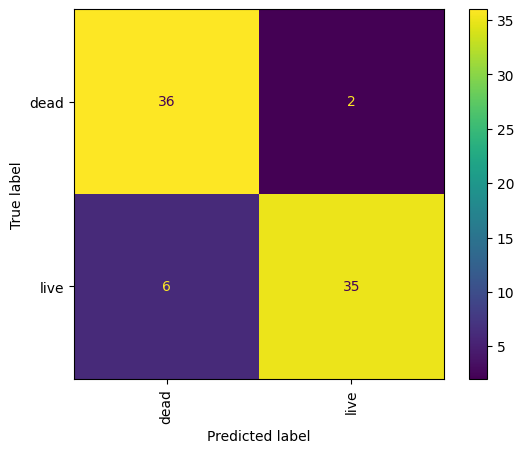

In [14]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
ConfusionMatrixDisplay.from_estimator(
    job.best_estimator_, X_test, y_test, xticks_rotation="vertical"
)